In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("D:\Meditrack ai 2\data\meditrack_equipment.csv")

In [3]:
df.shape

(303, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Equipment_ID           303 non-null    int64  
 1   Equipment_Name         303 non-null    object 
 2   Category               303 non-null    object 
 3   Department             299 non-null    object 
 4   Purchase_Date          303 non-null    object 
 5   Purchase_Cost          303 non-null    int64  
 6   Last_Maintenance_Date  287 non-null    object 
 7   Maintenance_Frequency  303 non-null    object 
 8   Maintenance_Cost       299 non-null    float64
 9   Downtime_Hours         303 non-null    float64
 10  Usage_Hours            303 non-null    float64
 11  Status                 303 non-null    object 
 12  Issue_Count            303 non-null    int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 30.9+ KB


In [5]:
df.describe()

,Equipment_ID,Purchase_Cost,Maintenance_Cost,Downtime_Hours,Usage_Hours,Issue_Count
count,303.000000,3.030000e+02,299.000000,303.000000,303.000000,303.000000
mean,149.828383,2.248548e+06,78605.662207,18.176898,1192.247525,1.663366
std,86.739296,4.908010e+06,66830.034723,48.939772,877.584413,1.275941
min,1.000000,1.009000e+03,1707.000000,0.800000,104.900000,0.000000
25%,75.500000,7.193750e+04,37114.000000,8.050000,599.200000,1.000000
50%,150.000000,2.889640e+05,76888.000000,13.500000,1197.100000,2.000000
75%,224.500000,1.194226e+06,115918.500000,21.500000,1700.750000,2.000000
max,300.000000,2.475133e+07,950000.000000,850.000000,12000.000000,8.000000


In [6]:
df.isnull().sum()

Equipment_ID              0
Equipment_Name            0
Category                  0
Department                4
Purchase_Date             0
Purchase_Cost             0
Last_Maintenance_Date    16
Maintenance_Frequency     0
Maintenance_Cost          4
Downtime_Hours            0
Usage_Hours               0
Status                    0
Issue_Count               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(3)

In [8]:
df[df.duplicated()]

,Equipment_ID,Equipment_Name,Category,Department,Purchase_Date,Purchase_Cost,Last_Maintenance_Date,Maintenance_Frequency,Maintenance_Cost,Downtime_Hours,Usage_Hours,Status,Issue_Count
300,21,Surgical Table,Surgical Equipment,General Ward,2019-06-02 10:10:46,456542,2026-08-20,Yearly,121530.0,8.2,307.6,Available,2
301,76,CT Scanner,Diagnostic Imaging,Emergency,2017-11-02 03:40:10,12578238,2026-06-27,Half-Yearly,5212.0,18.6,2158.2,Available,3
302,151,Infusion Pump,Drug Delivery,Neurology,2021-04-08 15:32:03,102709,2026-02-24,Yearly,142007.0,5.3,2140.2,In Use,2


In [9]:
df=df.drop_duplicates()

In [10]:
df["Purchase_Date"]=pd.to_datetime(df["Purchase_Date"])

In [11]:
df["Last_Maintenance_Date"]=pd.to_datetime(df["Last_Maintenance_Date"])

In [12]:
df[df["Department"].isnull()]

,Equipment_ID,Equipment_Name,Category,Department,Purchase_Date,Purchase_Cost,Last_Maintenance_Date,Maintenance_Frequency,Maintenance_Cost,Downtime_Hours,Usage_Hours,Status,Issue_Count
22,23,Patient Monitor,Monitoring,NaN,2018-09-15 10:03:44,119298,2026-03-03,Yearly,139210.0,23.4,125.9,Available,3
85,86,Patient Monitor,Monitoring,NaN,2022-12-08 13:19:59,136178,2026-04-13,Monthly,141680.0,7.6,1165.6,In Use,2
153,154,CT Scanner,Diagnostic Imaging,NaN,2018-09-10 21:27:18,24751329,2026-08-27,Quarterly,129459.0,19.1,1701.5,Available,2
287,288,Ventilator,Critical Care,NaN,2024-08-09 08:53:13,585623,2026-07-23,Quarterly,33250.0,4.6,1432.3,Available,0


In [13]:
df["Department"]=df["Department"].fillna("Unknown")

In [14]:
df[df["Last_Maintenance_Date"].isnull()]

,Equipment_ID,Equipment_Name,Category,Department,Purchase_Date,Purchase_Cost,Last_Maintenance_Date,Maintenance_Frequency,Maintenance_Cost,Downtime_Hours,Usage_Hours,Status,Issue_Count
56,57,ECG Machine,Diagnostic,Cardiology,2021-08-14 05:18:09,169657,NaT,Yearly,21008.0,5.2,969.7,In Use,1
58,59,X-Ray Machine,Diagnostic Imaging,General Ward,2024-07-15 03:39:25,2559599,NaT,Quarterly,9625.0,11.9,757.7,In Use,2
73,74,CT Scanner,Diagnostic Imaging,Radiology,2019-04-28 09:19:49,8497562,NaT,Half-Yearly,19272.0,24.8,2138.6,In Use,1
74,75,Electrosurgical Unit,Surgical Equipment,Pediatrics,2021-03-26 22:17:43,952965,NaT,Half-Yearly,105254.0,15.2,1724.4,Out of Service,1
90,91,Surgical Table,Surgical Equipment,Emergency,2018-02-27 05:45:41,778007,NaT,Yearly,98046.0,25.2,447.0,Under Maintenance,0
113,114,Oxygen Concentrator,Respiratory Equipment,Operation Theatre,2022-12-07 23:06:04,30404,NaT,Half-Yearly,60682.0,13.9,1666.3,Available,0
136,137,CT Scanner,Diagnostic Imaging,Cardiology,2021-02-02 09:02:49,21943554,NaT,Yearly,5154.0,14.0,1031.3,Available,2
143,144,Oxygen Concentrator,Respiratory Equipment,General Ward,2024-04-01 20:14:06,83871,NaT,Quarterly,13649.0,7.5,106.7,Available,4
146,147,Ventilator,Critical Care,Operation Theatre,2020-01-11 17:14:08,789542,NaT,Quarterly,72531.0,25.9,604.8,Available,3
161,162,Infusion Pump,Drug Delivery,Emergency,2024-12-19 01:57:38,108251,NaT,Quarterly,106611.0,15.2,800.2,In Use,2


In [15]:
df[df["Maintenance_Cost"].isnull()]

,Equipment_ID,Equipment_Name,Category,Department,Purchase_Date,Purchase_Cost,Last_Maintenance_Date,Maintenance_Frequency,Maintenance_Cost,Downtime_Hours,Usage_Hours,Status,Issue_Count
96,97,Electrosurgical Unit,Surgical Equipment,Pediatrics,2024-07-31 17:08:12,311813,2026-01-17,Half-Yearly,NaN,26.7,1743.0,Under Maintenance,1
101,102,Anesthesia Machine,Critical Care,Pediatrics,2024-09-24 14:32:56,785977,2026-06-11,Quarterly,NaN,15.5,1069.0,Available,1
237,238,Ultrasound Machine,Diagnostic Imaging,General Ward,2024-09-15 06:44:25,3087623,2026-04-07,Yearly,NaN,11.1,1615.6,Out of Service,0
279,280,Ventilator,Critical Care,General Ward,2023-06-21 03:43:54,717010,2026-01-03,Quarterly,NaN,8.2,1432.1,Under Maintenance,0


In [16]:
df.nlargest(5,"Downtime_Hours")[
    ["Equipment_ID", "Equipment_Name", "Category","Downtime_Hours"]
]

,Equipment_ID,Equipment_Name,Category,Downtime_Hours
25,26,Pulse Oximeter,Monitoring,850.0
190,191,CT Scanner,Diagnostic Imaging,55.6
68,69,Ultrasound Machine,Diagnostic Imaging,51.2
127,128,Blood Pressure Monitor,Monitoring,49.0
245,246,Infusion Pump,Drug Delivery,48.6


In [17]:
df.nlargest(5,"Usage_Hours")[
    ["Equipment_ID", "Equipment_Name", "Category","Usage_Hours"]
]

,Equipment_ID,Equipment_Name,Category,Usage_Hours
200,201,X-Ray Machine,Diagnostic Imaging,12000.0
92,93,Anesthesia Machine,Critical Care,2199.4
280,281,Patient Monitor,Monitoring,2198.9
141,142,ECG Machine,Diagnostic,2191.9
67,68,Anesthesia Machine,Critical Care,2189.2


In [18]:
df.nlargest(5, "Maintenance_Cost")[
    ["Equipment_ID", "Equipment_Name", "Category", "Maintenance_Cost","Purchase_Cost"]
]

,Equipment_ID,Equipment_Name,Category,Maintenance_Cost,Purchase_Cost
120,121,Anesthesia Machine,Critical Care,950000.0,1310006
61,62,Patient Monitor,Monitoring,149659.0,146203
260,261,Oxygen Concentrator,Respiratory Equipment,148735.0,64674
44,45,Electrosurgical Unit,Surgical Equipment,148149.0,888353
19,20,ECG Machine,Diagnostic,147970.0,214188


In [19]:
df["Maintenance_Cost"] = pd.to_numeric(
    df["Maintenance_Cost"],
    errors="coerce"
)

In [20]:
df["Maintenance_Cost"] = df["Maintenance_Cost"].fillna(
    df["Maintenance_Cost"].median()
)

In [21]:
analysis_date = pd.Timestamp("2026-09-17")

df["Equipment_Age_Years"] = (
    (analysis_date - df["Purchase_Date"]).dt.days / 365.25
).round(1)

In [22]:
df["Days_Since_Maintenance"] = (
    analysis_date - df["Last_Maintenance_Date"]
).dt.days

In [23]:
df[["Equipment_Name", "Last_Maintenance_Date", "Days_Since_Maintenance"]].head()

,Equipment_Name,Last_Maintenance_Date,Days_Since_Maintenance
0,Infusion Pump,2026-08-28,20.0
1,Defibrillator,2026-03-28,173.0
2,Blood Pressure Monitor,2026-07-31,48.0
3,Electrosurgical Unit,2026-07-16,63.0
4,Syringe Pump,2026-05-20,120.0


In [24]:
df["Maintenance_Status"] = np.select(
    [
        df["Last_Maintenance_Date"].isna(),
        df["Days_Since_Maintenance"] > 180,
        df["Days_Since_Maintenance"] >= 150
    ],
    [
        "No Maintenance Record",
        "Overdue",
        "Due Soon"
    ],
    default="Good"
)

In [25]:
df["Maintenance_Cost_Ratio"] = (
    df["Maintenance_Cost"] / df["Purchase_Cost"] * 100
).round(2)

In [26]:
df[
    [
        "Equipment_Name",
        "Equipment_Age_Years",
        "Days_Since_Maintenance",
        "Maintenance_Status",
        "Maintenance_Cost_Ratio"
    ]
].head(10)

,Equipment_Name,Equipment_Age_Years,Days_Since_Maintenance,Maintenance_Status,Maintenance_Cost_Ratio
0,Infusion Pump,2.5,20.0,Good,69.50
1,Defibrillator,8.7,173.0,Due Soon,41.09
2,Blood Pressure Monitor,8.5,48.0,Good,1961.38
3,Electrosurgical Unit,6.5,63.0,Good,17.34
4,Syringe Pump,4.8,120.0,Good,64.76
5,Oxygen Concentrator,3.1,159.0,Due Soon,166.51
6,Blood Pressure Monitor,6.2,42.0,Good,1926.30
7,X-Ray Machine,8.6,248.0,Overdue,0.04
8,Infusion Pump,1.3,236.0,Overdue,258.02
9,Anesthesia Machine,4.2,90.0,Good,5.93


In [27]:
df["Maintenance_Status"].value_counts()

Maintenance_Status
Good                     171
Overdue                   80
Due Soon                  33
No Maintenance Record     16
Name: count, dtype: int64

In [28]:
df[
    [
        "Equipment_Age_Years",
        "Days_Since_Maintenance",
        "Maintenance_Cost_Ratio"
    ]
].describe()

,Equipment_Age_Years,Days_Since_Maintenance,Maintenance_Cost_Ratio
count,300.00000,284.000000,300.000000
mean,5.27300,130.411972,261.732433
std,2.68365,72.352709,869.890595
min,0.70000,11.000000,0.020000
25%,2.87500,68.000000,3.832500
50%,5.30000,127.500000,21.330000
75%,7.70000,196.000000,107.305000
max,9.70000,259.000000,9433.100000


In [29]:
df.nlargest(5, "Maintenance_Cost_Ratio")[
    [
        "Equipment_ID",
        "Equipment_Name",
        "Category",
        "Purchase_Cost",
        "Maintenance_Cost",
        "Maintenance_Cost_Ratio"
    ]
]

,Equipment_ID,Equipment_Name,Category,Purchase_Cost,Maintenance_Cost,Maintenance_Cost_Ratio
89,90,Pulse Oximeter,Monitoring,1009,95180.0,9433.10
199,200,Pulse Oximeter,Monitoring,1666,113856.0,6834.09
112,113,Pulse Oximeter,Monitoring,1384,65606.0,4740.32
226,227,Pulse Oximeter,Monitoring,3286,133233.0,4054.56
46,47,Pulse Oximeter,Monitoring,2256,89509.0,3967.60


In [30]:
category_counts = df["Category"].value_counts()

category_counts

Category
Diagnostic Imaging       70
Monitoring               56
Drug Delivery            43
Critical Care            41
Surgical Equipment       32
Respiratory Equipment    22
Diagnostic               19
Emergency Equipment      17
Name: count, dtype: int64

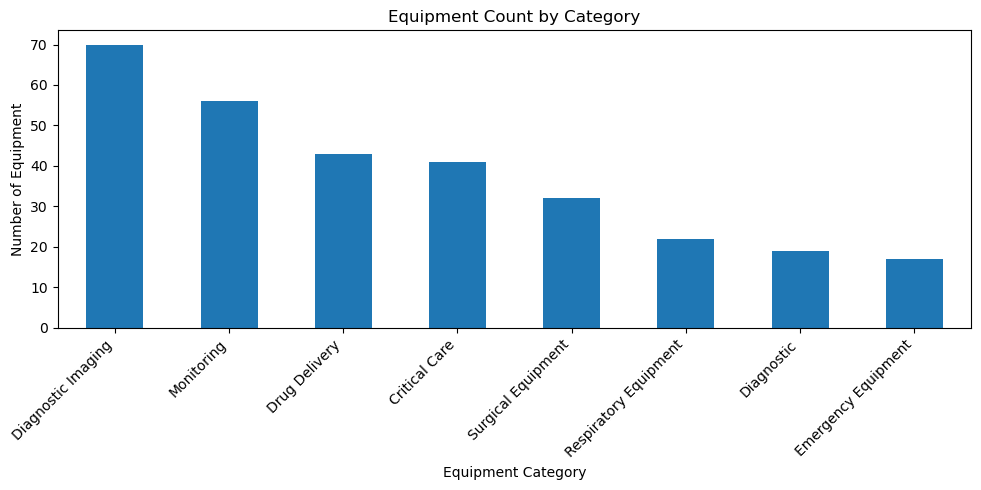

In [31]:
plt.figure(figsize=(10, 5))

category_counts.plot(kind="bar")

plt.title("Equipment Count by Category")
plt.xlabel("Equipment Category")
plt.ylabel("Number of Equipment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
maintenance_by_category = (
    df.groupby("Category")["Maintenance_Cost"]
      .sum()
      .sort_values(ascending=False)
)

maintenance_by_category

Category
Diagnostic Imaging       5132282.0
Monitoring               4353289.0
Critical Care            4040648.0
Drug Delivery            3419154.0
Surgical Equipment       2344531.0
Diagnostic               1444897.0
Respiratory Equipment    1408244.0
Emergency Equipment      1397115.0
Name: Maintenance_Cost, dtype: float64

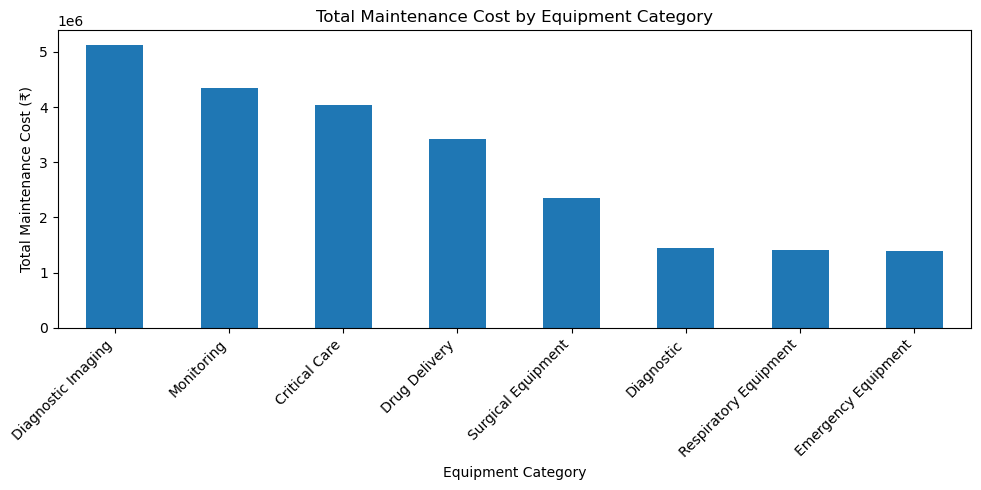

In [33]:
plt.figure(figsize=(10, 5))

maintenance_by_category.plot(kind="bar")

plt.title("Total Maintenance Cost by Equipment Category")
plt.xlabel("Equipment Category")
plt.ylabel("Total Maintenance Cost (₹)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
maintenance_by_category.idxmax(), maintenance_by_category.max()

('Diagnostic Imaging', 5132282.0)

In [35]:
maintenance_status_counts = df["Maintenance_Status"].value_counts()

maintenance_status_counts

Maintenance_Status
Good                     171
Overdue                   80
Due Soon                  33
No Maintenance Record     16
Name: count, dtype: int64

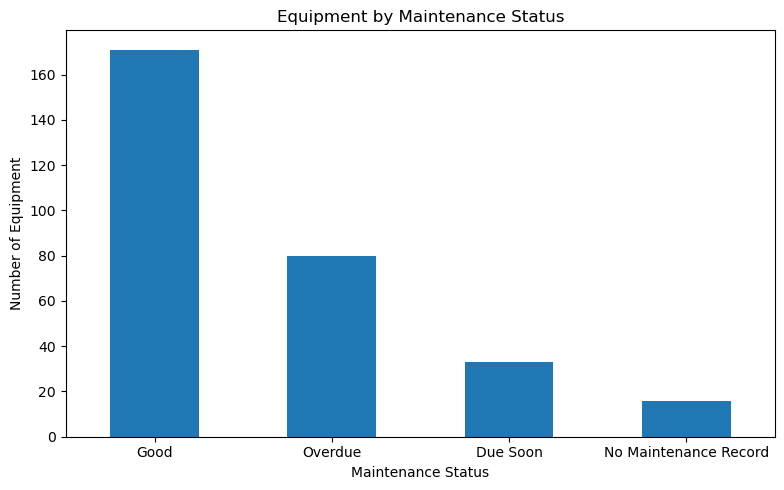

In [36]:
plt.figure(figsize=(8, 5))

maintenance_status_counts.plot(kind="bar")

plt.title("Equipment by Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Number of Equipment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
maintenance_status_percentage = (
    df["Maintenance_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

maintenance_status_percentage

Maintenance_Status
Good                     57.00
Overdue                  26.67
Due Soon                 11.00
No Maintenance Record     5.33
Name: proportion, dtype: float64

In [38]:
downtime_by_department = (
    df.groupby("Department")["Downtime_Hours"]
      .sum()
      .sort_values(ascending=False)
)

downtime_by_department

Department
Pediatrics           1418.2
Operation Theatre     756.2
General Ward          609.3
ICU                   573.6
Emergency             557.9
Cardiology            540.5
Neurology             507.5
Radiology             457.6
Unknown                54.7
Name: Downtime_Hours, dtype: float64

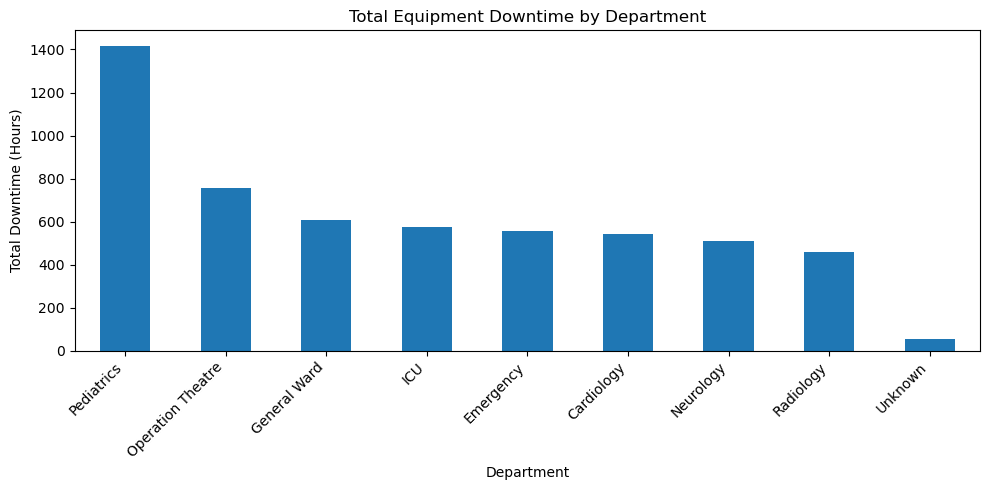

In [39]:
plt.figure(figsize=(10, 5))

downtime_by_department.plot(kind="bar")

plt.title("Total Equipment Downtime by Department")
plt.xlabel("Department")
plt.ylabel("Total Downtime (Hours)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [42]:
print("Highest maintenance cost category:", maintenance_by_category.idxmax())
print("Highest maintenance cost:", maintenance_by_category.max())

print("Highest downtime department:", downtime_by_department.idxmax())
print("Highest downtime:", downtime_by_department.max())


Highest maintenance cost category: Diagnostic Imaging
Highest maintenance cost: 5132282.0
Highest downtime department: Pediatrics
Highest downtime: 1418.2


In [43]:
df.to_csv("D:\Meditrack ai 2\data/meditrack_equipment_cleaned.csv", index=False)